In [80]:
!pip install torch torchvision torchaudio

In [81]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns

In [82]:
#from google.colab import drive
#drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [83]:
#path to the data
#assume this data dir pipeline_output_final/final_metadata.csv and pipeline_output_final/batch_*.npz are in data_dir
DATA_DIR = "/content/drive/MyDrive/project3/kepler_dataset_v1"  # Make sure this matches your folder name!

In [84]:
class ExoplanetData(Dataset):

# (self.global_data, etc.), and keeps them in RAM.
    def __init__(self, data_dir):
        """
        Args:
            data_dir: Directory containing the .npz batch files
        """
        self.data_dir = data_dir
        self.meta = pd.read_csv(os.path.join(data_dir, "final_metadata.csv"))

        print("Pre-loading data into RAM...")
        self.global_data = []
        self.local_data = []
        self.labels = []

        for filename, group in self.meta.groupby('filename'):
            filepath = os.path.join(data_dir, filename)
            try:
                with np.load(filepath) as data:
                    batch_flux_global = data['flux_global']
                    batch_flux_local = data['flux_local']
                    batch_labels = data['label']

                    for _, row in group.iterrows():
                        idx = int(row['index_in_batch'])
                        self.global_data.append(batch_flux_global[idx])
                        self.local_data.append(batch_flux_local[idx])
                        self.labels.append(batch_labels[idx])
            except Exception as e:
                print(f"Error loading {filename}: {e}")


        self.global_data = torch.tensor(np.array(self.global_data), dtype=torch.float32).unsqueeze(1)
        self.local_data = torch.tensor(np.array(self.local_data), dtype=torch.float32).unsqueeze(1)
        self.labels = torch.tensor(np.array(self.labels), dtype=torch.float32)

        #Added Safety Check for NaNs (Not a Number)
        if torch.isnan(self.global_data).any() or torch.isnan(self.local_data).any():
            print("WARNING: Found NaNs in data. Replacing with 0.0 (Mean value).")
            self.global_data = torch.nan_to_num(self.global_data, nan=0.0)
            self.local_data = torch.nan_to_num(self.local_data, nan=0.0)

        print(f"Loaded {len(self.labels)} samples.")
        print(f"Global Shape: {self.global_data.shape}")
        print(f"Local Shape: {self.local_data.shape}")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Now returns the pre-loaded data from RAM.
        return self.global_data[idx], self.local_data[idx], self.labels[idx]



In [85]:
# CNN MODEL
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # Local Column (Input: 1 x 201)
        self.local_conv = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5), nn.ReLU(),
            nn.Conv1d(16, 16, kernel_size=5), nn.ReLU(),
            nn.MaxPool1d(kernel_size=7, stride=2)
        )

        # Global Column (Input: 1 x 2001)
        self.global_conv = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5), nn.ReLU(),
            nn.Conv1d(16, 16, kernel_size=5), nn.ReLU(),
            nn.MaxPool1d(kernel_size=5, stride=2),

            nn.Conv1d(16, 32, kernel_size=5), nn.ReLU(),
            nn.Conv1d(32, 32, kernel_size=5), nn.ReLU(),
            nn.MaxPool1d(kernel_size=5, stride=2)
        )

        # Calculate Flattened Sizes Dynamically (Self-correcting)
        # We pass a dummy input to see what the size comes out as
        # This code runs a "fake" piece of data through the layers to measure the output size automatically.
        with torch.no_grad():
            dummy_local = torch.zeros(1, 1, 201)
            dummy_global = torch.zeros(1, 1, 2001)
            out_local = self.local_conv(dummy_local)
            out_global = self.global_conv(dummy_global)

            self.flat_local_size = out_local.view(1, -1).shape[1]
            self.flat_global_size = out_global.view(1, -1).shape[1]

        print(f"Calculated Flatten Sizes -> Local: {self.flat_local_size}, Global: {self.flat_global_size}")

        # FC Layers
        self.fc = nn.Sequential(
            nn.Linear(self.flat_local_size + self.flat_global_size, 512),
            nn.ReLU(),
            nn.Linear(512, 512), nn.ReLU(),
            nn.Linear(512, 512), nn.ReLU(),
            nn.Linear(512, 1) # Output logit (no sigmoid here, handled by loss function)
        )

    def forward(self, global_x, local_x):
        # Local
        lx = self.local_conv(local_x)
        lx = torch.flatten(lx, 1)

        # Global
        gx = self.global_conv(global_x)
        gx = torch.flatten(gx, 1)

        # Combine
        x = torch.cat((lx, gx), 1)
        return self.fc(x)


In [86]:
#===============
#evaluation function
#===============
def evaluate(pred_labels, y_list):
    pred_labels = np.array(pred_labels)
    y_list = np.array(y_list)
    TP = ((pred_labels == 1) & (y_list == 1)).astype(float).sum()
    FP = ((pred_labels == 1) & (y_list == 0)).astype(float).sum()
    TN = ((pred_labels == 0) & (y_list == 0)).astype(float).sum()
    FN = ((pred_labels == 0) & (y_list == 1)).astype(float).sum()

    accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-8)
    precision = TP / (TP + FP + 1e-8)
    recall_1 = TP / (TP + FN + 1e-8)
    recall_0 = TN / (TN + FP + 1e-8)
    F1 = 2 * precision * recall_1 / (precision + recall_1 + 1e-8)

    return accuracy, precision, recall_1, recall_0, F1

In [87]:
# TRAINING and VISUALIZATION
# Hyperparameters
LEARNING_RATE = 0.001
NUM_EPOCHS = 50
BATCH_SIZE = 64

# Load Data
full_dataset = ExoplanetData(DATA_DIR)

# Splits
train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(full_dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

# Init Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

model = CNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Metrics Storage
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'recall_1_train':[], 'recall_0_train':[], 'recall_1_val':[], 'recall_0_val':[], 'train_label_ratio_of_1':[], 'val_label_ratio_of_1':[]}

# Loop
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    pred_epoch_train = []
    y_true_epoch_train = []
    pred_epoch_val = []
    y_true_epoch_val = []
    num_neg_train = 0
    num_pos_train = 0
    num_neg_val = 0
    num_pos_val = 0

    for g_x, l_x, y in train_loader:
        g_x, l_x, y = g_x.to(device), l_x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(g_x, l_x).view(-1)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        #num_pos_train += (y == 1).float().sum().item()
        #num_neg_train += (y == 0).float().sum().item()
        #print(f"In the train batch,  number of label 1 = {num_pos}, number of label 0 = {num_neg}")

        running_loss += loss.item() * y.size(0)
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        #print(f"predicted in train= {predicted}")
        pred_epoch_train.extend(predicted.cpu().numpy())
        y_true_epoch_train.extend(y.cpu().numpy())
        correct += (predicted == y).sum().item()
        total += y.size(0)

    accuracy, precision, recall_1_train, recall_0_train, F1 = evaluate(pred_epoch_train, y_true_epoch_train)
    history['recall_1_train'].append(recall_1_train)
    history['recall_0_train'].append(recall_0_train)
    history['train_label_ratio_of_1'].append(num_pos_train / (num_pos_train + num_neg_train))
    #print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall_1: {recall_1:.4f}, Recall_0: {recall_0:.4f}, F1: {F1:.4f}")

    train_loss = running_loss / total
    train_acc = correct / total

    # Validation
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for g_x, l_x, y in val_loader:
            g_x, l_x, y = g_x.to(device), l_x.to(device), y.to(device)
            outputs = model(g_x, l_x).view(-1)
            loss = criterion(outputs, y)

            #num_pos_val += (y == 1).float().sum().item()
            #num_neg_val += (y == 0).float().sum().item()
            #print(f"In the val batch,  number of label 1 = {num_pos}, number of label 0 = {num_neg}")

            val_loss += loss.item() * y.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            #print(f"predicted in val= {predicted}")
            pred_epoch_val.extend(predicted.cpu().numpy())
            y_true_epoch_val.extend(y.cpu().numpy())
            val_correct += (predicted == y).sum().item()
            val_total += y.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    accuracy, precision, recall_1_val, recall_0_val, F1 = evaluate(pred_epoch_val, y_true_epoch_val)
    history['recall_1_val'].append(recall_1_val)
    history['recall_0_val'].append(recall_0_val)
    history['val_label_ratio_of_1'].append(num_pos_val / (num_pos_val + num_neg_val))


    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} Recall_1: {recall_1_train} Recall_0: {recall_0_train}| Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}Recall_1: {recall_1_val} Recall_0: {recall_0_val}")

Pre-loading data into RAM...
Loaded 1165 samples.
Global Shape: torch.Size([1165, 1, 2001])
Local Shape: torch.Size([1165, 1, 201])
Training on: cpu
Calculated Flatten Sizes -> Local: 1504, Global: 15744
Epoch 1/50 | Train Loss: 0.4968 Acc: 0.8401 Recall_1: 0.9987228607790712 Recall_0: 0.006711409395522724| Val Loss: 0.4254 Acc: 0.8621Recall_1: 0.9999999999000001 Recall_0: 0.0
Epoch 2/50 | Train Loss: 0.4352 Acc: 0.8412 Recall_1: 0.9974457215709138 Recall_0: 0.02013422818656817| Val Loss: 0.4037 Acc: 0.8534Recall_1: 0.9899999999010001 Recall_0: 0.0
Epoch 3/50 | Train Loss: 0.4244 Acc: 0.8444 Recall_1: 0.9961685823627564 Recall_0: 0.04697986576865907| Val Loss: 0.4069 Acc: 0.8621Recall_1: 0.9999999999000001 Recall_0: 0.0
Epoch 4/50 | Train Loss: 0.4263 Acc: 0.8423 Recall_1: 0.9999999999872285 Recall_0: 0.013422818791045447| Val Loss: 0.3719 Acc: 0.8534Recall_1: 0.9899999999010001 Recall_0: 0.0
Epoch 5/50 | Train Loss: 0.3890 Acc: 0.8541 Recall_1: 0.9859514686974974 Recall_0: 0.161073825

label ratio of 1:0.8401287553648069
label ratio of 1:0.8620689655172413


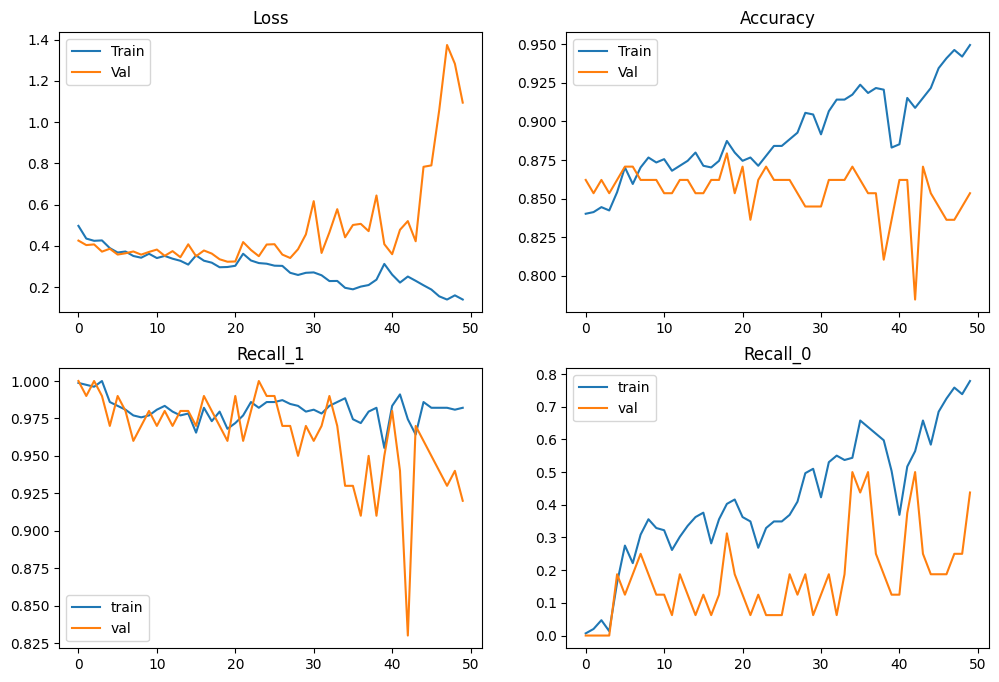

In [92]:
# Plotting
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(history['train_acc'], label='Train')
plt.plot(history['val_acc'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(history['recall_1_train'], label = 'train')
plt.plot(history['recall_1_val'], label = 'val')
plt.title('Recall_1')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(history['recall_0_train'], label = 'train')
plt.plot(history['recall_0_val'], label = 'val')
plt.title('Recall_0')
plt.legend()

print(f"label ratio of 1:{history['train_label_ratio_of_1'][0]}")
print(f"label ratio of 1:{history['val_label_ratio_of_1'][0]}")

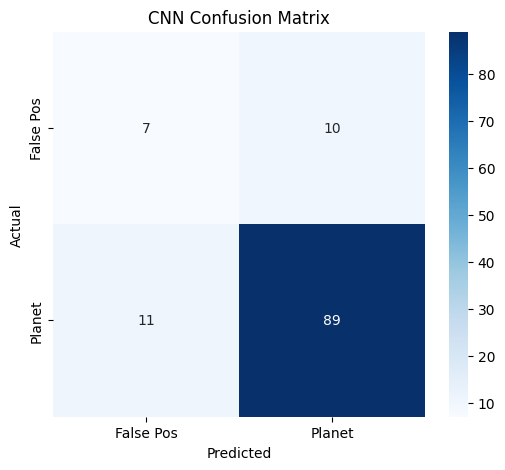

Accuracy: 0.8205, Precision: 0.8990, Recall_1: 0.8900, Recall_0: 0.4118, F1: 0.8945
g_sample min/max/mean: -0.27605247497558594 0.2843024432659149 0.036239780485630035
l_sample min/max/mean: -0.9543254971504211 0.7760406136512756 0.05025778338313103


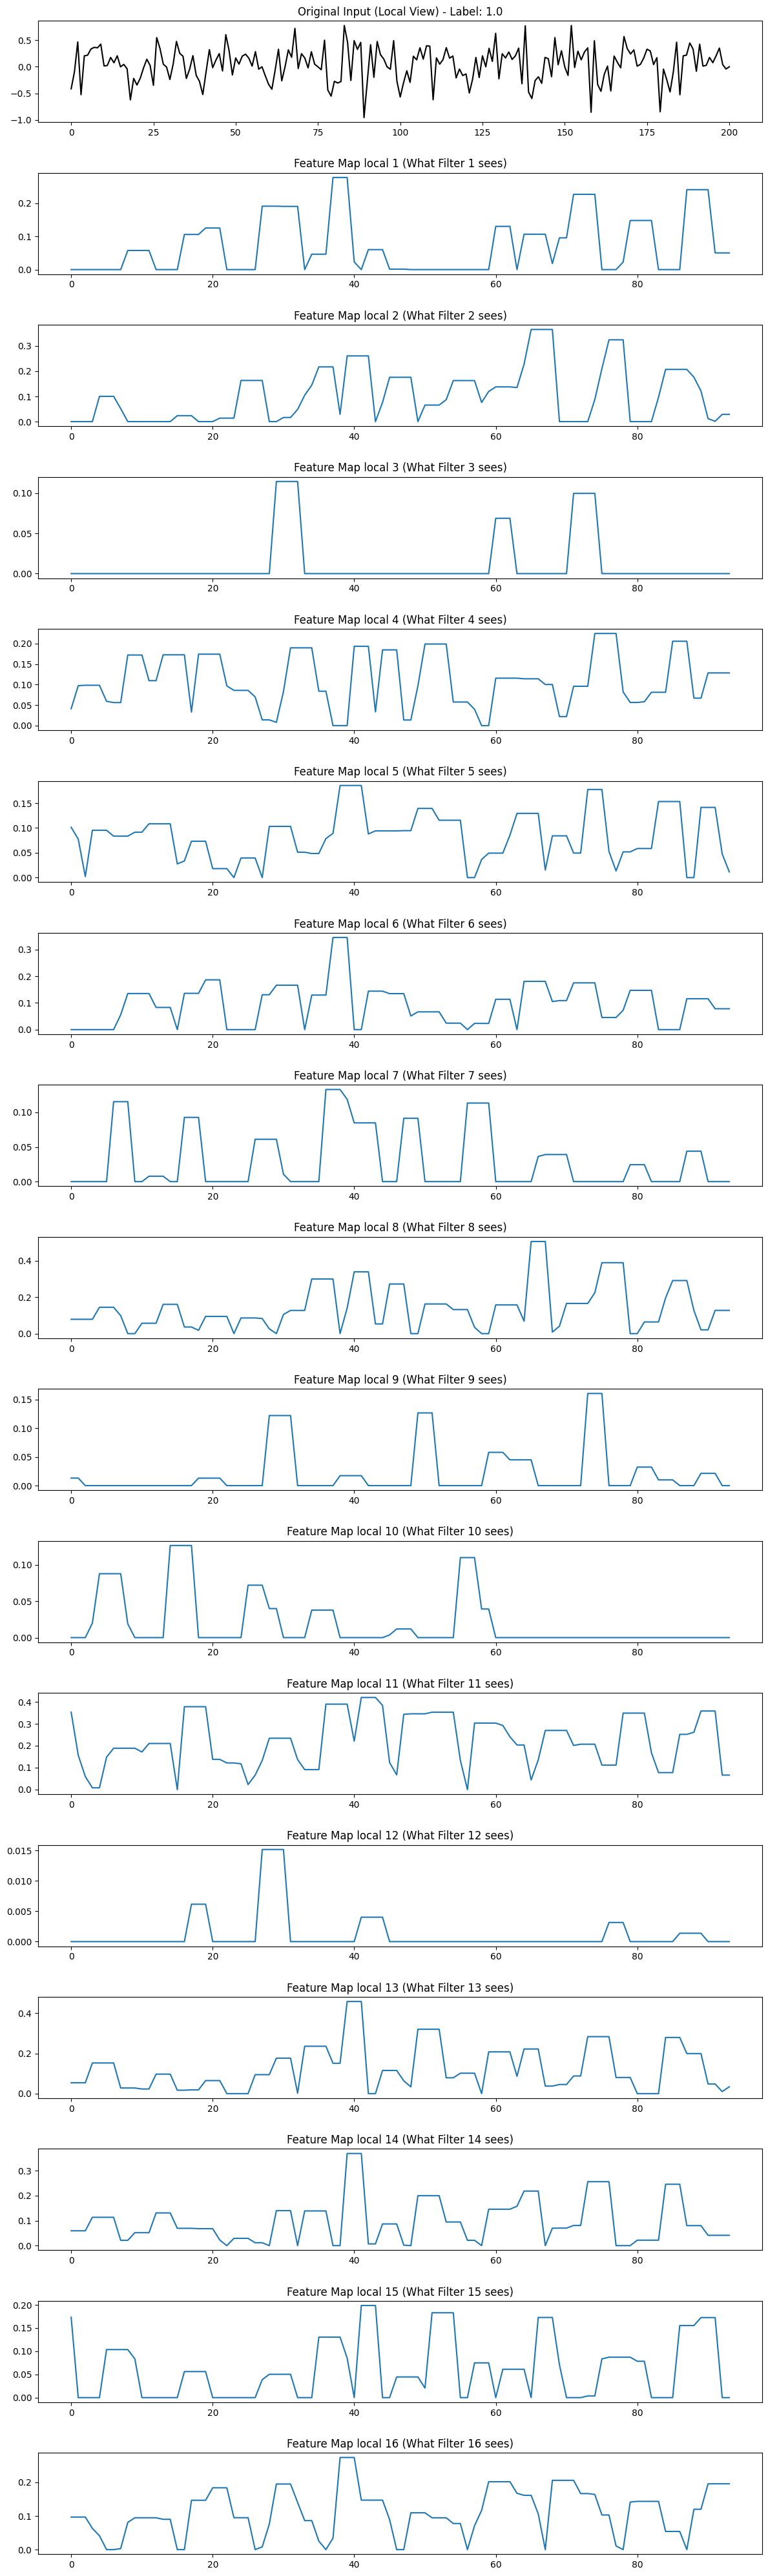

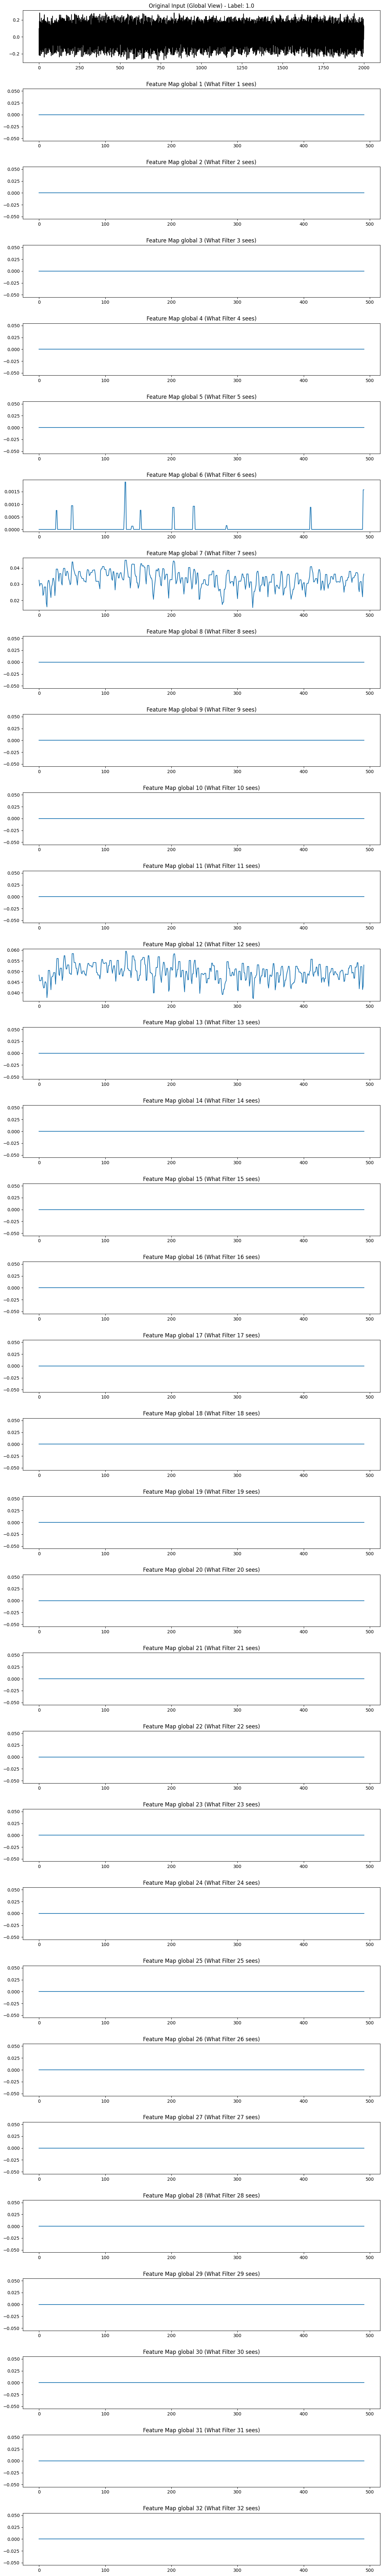

In [89]:

#Confusion Matrix (On Test Set)
# Allows us to see "How many False Positives did we think were planets?"
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for g_x, l_x, y in test_loader:
        g_x, l_x, y = g_x.to(device), l_x.to(device), y.to(device)
        outputs = model(g_x, l_x).view(-1)
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        #print(f"predicted in val= {predicted}")
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y.cpu().numpy())


accuracy, precision, recall_1_val, recall_0_val, F1 = evaluate(all_preds, all_labels)

cm = confusion_matrix(all_labels, all_preds, labels = [0,1])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['False Pos', 'Planet'], yticklabels=['False Pos', 'Planet'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('CNN Confusion Matrix')
plt.show()

print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall_1: {recall_1_val:.4f}, Recall_0: {recall_0_val:.4f}, F1: {F1:.4f}")

# Convolution Filter Visualization
# Local View filters

# Get a real planet sample from the dataset
sample_idx = 0
while full_dataset[sample_idx][2] == 0: # Find a Label 1 (Planet)
    sample_idx += 1

g_sample, l_sample, label = full_dataset[5]

print("g_sample min/max/mean:", g_sample.min().item(), g_sample.max().item(), g_sample.mean().item())
print("l_sample min/max/mean:", l_sample.min().item(), l_sample.max().item(), l_sample.mean().item())


# We need to add a batch dimension (unsqueeze) because the model expects batches
input_local = l_sample.unsqueeze(0).to(device)
input_global = g_sample.unsqueeze(0).to(device)

# Access the ouput of convolutional layer before mlp
with torch.no_grad():
    feature_maps_local = model.local_conv(input_local)
    feature_maps_global = model.global_conv(input_global)

feature_maps_local = feature_maps_local.squeeze(0).cpu()
feature_maps_global = feature_maps_global.squeeze(0).cpu()

# Plot the original input vs the each feature maps
plt.figure(figsize=(12, 40))

plt.subplot(17, 1, 1)
plt.plot(l_sample.squeeze().numpy(), color='black')
plt.title(f"Original Input (Local View) - Label: {label}")

for i in range(16): # Plot first 16 filters
    plt.subplot(17, 1, i+2)
    plt.plot(feature_maps_local[i])
    plt.title(f"Feature Map local {i+1} (What Filter {i+1} sees)")

plt.tight_layout()
plt.subplots_adjust(hspace=0.5)
plt.show()

plt.figure(figsize=(12, 80))

plt.subplot(33, 1, 1)
plt.plot(g_sample.squeeze().numpy(), color='black')
plt.title(f"Original Input (Global View) - Label: {label}")

for i in range(32):
    plt.subplot(33, 1, i+2)
    plt.plot(feature_maps_global[i])
    plt.title(f"Feature Map global {i+1} (What Filter {i+1} sees)")

plt.tight_layout()
plt.subplots_adjust(hspace=0.5)
plt.show()